# Quotients and Homomorphic Images
## Forgetting structure on purpose

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/courses/blob/main/2026fall/mat5173/downloads/public/activities/quotients-and-homomorphic-images.ipynb)
[![License: CC BY 4.0](https://img.shields.io/badge/License-CC%20BY%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by/4.0/)

---

A **quotient group** $G/N$ is what you get when you decide to stop
distinguishing elements that differ by something in $N$. A **homomorphic
image** is what you see when you look at $G$ through a map that forgets some
of its structure. The first isomorphism theorem says these are the same idea:

$$G/\ker\varphi \;\cong\; \operatorname{im}\varphi .$$

This notebook works that slogan through four examples you can compute with and,
in two cases, *see*:

1. $\mathbb{Z}/n$ — the arithmetic template everyone already knows.
2. **Orientation-preserving isometries of the plane.** Forget *where* a figure
   is and keep only how it has been *turned*: $\mathrm{Isom}^+/\mathrm{Trans}
   \cong S^1$.
3. **Spiral similarities.** $\mathrm{Spiral} \cong \mathrm{Rotn} \times
   \mathrm{Dilat}^+$, so each factor is the quotient by the other.
4. **The sign of a permutation** — $S_4/A_4 \cong \{\pm 1\}$.

Nothing here has a grade attached and there is nothing to submit. Work alone or
in a group, and skip around. *Runtime → Run all* always resets you to a clean
state.



## How to read every example below

Each one has the same four moving parts. Naming them as you go is most of the
work:

| part | what to ask |
|---|---|
| the group $G$ | what are the elements, and what is the operation? |
| the map $\varphi$ | what does it *remember*? |
| the kernel $N = \ker\varphi$ | what does it *forget*? |
| the image | what is left — and is it something you recognise? |

The kernel is automatically a **normal** subgroup, which is exactly what makes
$G/N$ a group at all. Watch for that in example 2: it is the reason the
construction works, not a technicality.


In [1]:
import cmath
import itertools
import numpy as np
import matplotlib.pyplot as plt

TAU = 2 * np.pi

def approx(a, b, tol=1e-9):
    "Complex/float comparison that tolerates floating-point noise."
    return abs(a - b) < tol

# An asymmetric figure, so that a rotation is visible as a rotation
# (a disc or a square would hide most of what we do below).
FLAG = np.array([0, 1, 1 + 0.15j, 0.25 + 0.15j, 0.25 + 0.55j, 0.6 + 0.55j,
                 0.25 + 0.55j, 0.25 + 0.15j, 0])

def draw(ax, pts, color="steelblue", lw=2, alpha=1.0, label=None):
    ax.plot(np.real(pts), np.imag(pts), color=color, lw=lw, alpha=alpha, label=label)

print("ready")


ready


# 1. The template: $\mathbb{Z}/n$ as a quotient of $\mathbb{Z}$

Take $G = (\mathbb{Z}, +)$ and $\varphi(k) = k \bmod n$. Then

$$\varphi(j + k) = \varphi(j) + \varphi(k) \pmod n,$$

so $\varphi$ is a homomorphism onto $\mathbb{Z}/n$, and
$\ker\varphi = n\mathbb{Z}$. The cosets of $n\mathbb{Z}$ *are* the residue
classes: $k + n\mathbb{Z}$ is "all the integers that agree with $k$ about
remainder mod $n$."

$$\mathbb{Z}/n\mathbb{Z} \;=\; \mathbb{Z}/\ker\varphi \;\cong\;
\operatorname{im}\varphi \;=\; \{0, 1, \dots, n-1\}.$$


In [2]:
n = 6

# The cosets of nZ inside Z, sampled over a window.
window = range(-12, 13)
cosets = {r: sorted(k for k in window if k % n == r) for r in range(n)}
for r, members in cosets.items():
    print(f"{r} + {n}Z  ->  {members}")

# The homomorphism property, checked exhaustively on the window.
bad = [(j, k) for j in window for k in window if (j + k) % n != ((j % n) + (k % n)) % n]
print("\nhomomorphism failures:", bad if bad else "none")


0 + 6Z  ->  [-12, -6, 0, 6, 12]
1 + 6Z  ->  [-11, -5, 1, 7]
2 + 6Z  ->  [-10, -4, 2, 8]
3 + 6Z  ->  [-9, -3, 3, 9]
4 + 6Z  ->  [-8, -2, 4, 10]
5 + 6Z  ->  [-7, -1, 5, 11]

homomorphism failures: none


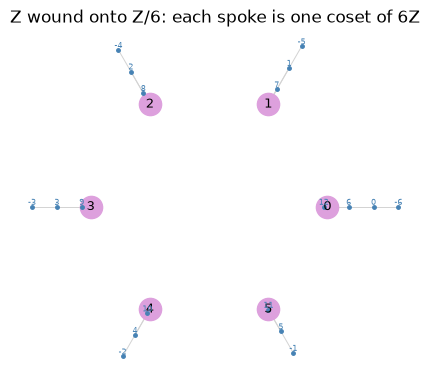

In [3]:
# Winding Z onto n points: every integer lands on its residue class.
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ring = np.exp(1j * TAU * np.arange(n) / n)
ax.plot(np.real(ring), np.imag(ring), "o", ms=16, color="plum", zorder=2)
for r in range(n):
    ax.annotate(str(r), (ring[r].real, ring[r].imag), ha="center", va="center",
                fontsize=9, zorder=3)

# a few integers, drawn spiralling in to the class they belong to
for k in range(-6, 13):
    z = np.exp(1j * TAU * k / n) * (1.6 - 0.035 * (k + 6))
    ax.plot([z.real, ring[k % n].real], [z.imag, ring[k % n].imag],
            color="lightgray", lw=0.7, zorder=1)
    ax.plot(z.real, z.imag, ".", color="steelblue", ms=5, zorder=2)
    ax.annotate(str(k), (z.real, z.imag), fontsize=6, color="steelblue",
                ha="center", va="bottom")

ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Z wound onto Z/{n}: each spoke is one coset of {n}Z")
plt.show()


# 2. Orientation-preserving isometries: $\mathrm{Isom}^+/\mathrm{Trans} \cong S^1$

Identify the plane with $\mathbb{C}$. Every **orientation-preserving isometry**
is

$$f(z) = e^{i\theta} z + b, \qquad \theta \in \mathbb{R},\; b \in \mathbb{C},$$

a rotation by $\theta$ followed by a translation by $b$. Composing two of them,

$$(f_1 \circ f_2)(z) = e^{i(\theta_1 + \theta_2)} z + \bigl(e^{i\theta_1} b_2 + b_1\bigr),$$

the translation parts mix together in a complicated way — but **the angles just
add**. So

$$\varphi(f) = e^{i\theta}$$

is a homomorphism $\mathrm{Isom}^+ \to S^1$. It remembers *how much the figure
got turned* and forgets *where it ended up*.

Its kernel is $\theta \equiv 0$, i.e. the maps $z \mapsto z + b$: the
translation group $\mathrm{Trans} \cong (\mathbb{C}, +) \cong \mathbb{R}^2$.
Hence

$$\mathrm{Isom}^+/\mathrm{Trans} \;\cong\; S^1 \;\cong\; \mathrm{SO}(2)
\;\cong\; \mathrm{Rotn}.$$

**Read that as a sentence about pictures.** Two isometries lie in the same coset
of $\mathrm{Trans}$ exactly when they leave a figure in the same *angular
orientation*, no matter where on the page it sits. Ignoring translations,
orientation is a point of the circle.


In [4]:
class Isom:
    "z -> e^{i*theta} z + b, an orientation-preserving isometry of the plane."
    def __init__(self, theta, b=0j):
        self.theta = theta % TAU
        self.b = complex(b)

    def __call__(self, z):
        return np.exp(1j * self.theta) * z + self.b

    def __mul__(self, other):                      # self AFTER other
        return Isom(self.theta + other.theta,
                    np.exp(1j * self.theta) * other.b + self.b)

    def phi(self):                                 # the angle homomorphism
        return np.exp(1j * self.theta)

    def __repr__(self):
        return f"Isom(theta={self.theta:.3f}, b={self.b:.3f})"

rng = np.random.default_rng(0)
sample = [Isom(rng.uniform(0, TAU), complex(rng.normal(), rng.normal()))
          for _ in range(200)]

# phi(f*g) == phi(f)*phi(g)?
fails = [(f, g) for f, g in itertools.islice(itertools.product(sample, sample), 4000)
         if not approx((f * g).phi(), f.phi() * g.phi())]
print("homomorphism failures:", len(fails))

# The kernel is exactly the translations.
translations = [Isom(0.0, complex(rng.normal(), rng.normal())) for _ in range(50)]
print("every translation in ker(phi)?", all(approx(t.phi(), 1 + 0j) for t in translations))

# Normality, which is what makes the quotient a group: f t f^-1 is a translation.
f = sample[0]
finv = Isom(-f.theta, -np.exp(-1j * f.theta) * f.b)
conj = [f * t * finv for t in translations[:10]]
print("f T f^-1 still translations?", all(approx(c.phi(), 1 + 0j) for c in conj))


homomorphism failures: 0
every translation in ker(phi)? True
f T f^-1 still translations? True


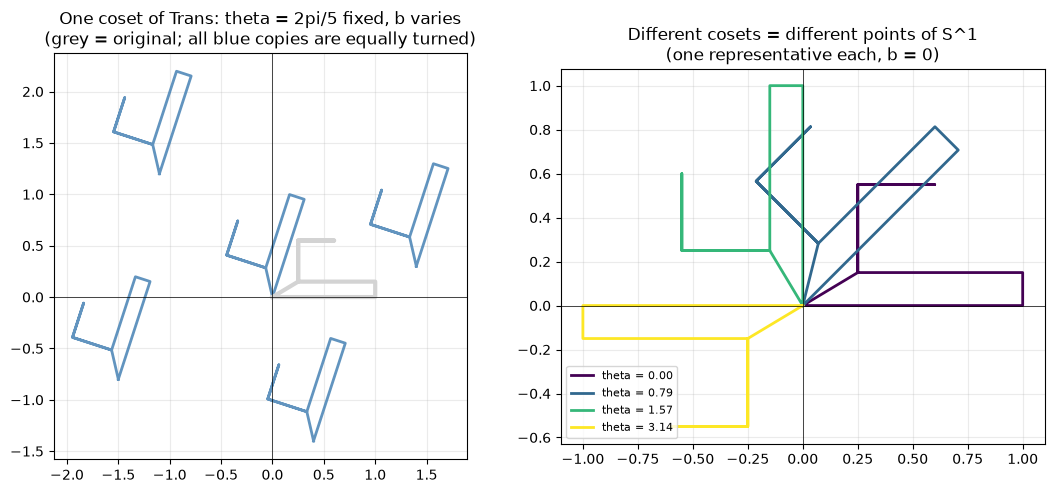

In [5]:
# One coset of Trans, drawn: same theta, many different b.
theta = TAU / 5
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
for b in [0, 1.4 + 0.3j, -1.1 + 1.2j, 0.4 - 1.4j, -1.5 - 0.8j]:
    draw(ax, Isom(theta, b)(FLAG), color="steelblue", alpha=0.85)
draw(ax, FLAG, color="lightgray", lw=3)
ax.set_title(f"One coset of Trans: theta = 2pi/5 fixed, b varies\n"
             "(grey = original; all blue copies are equally turned)")

# A different coset: a different theta.
ax = axes[1]
for k, th in enumerate([0.0, TAU / 8, TAU / 4, TAU / 2]):
    draw(ax, Isom(th, 0)(FLAG), color=plt.cm.viridis(k / 3), label=f"theta = {th:.2f}")
ax.legend(fontsize=8, loc="lower left")
ax.set_title("Different cosets = different points of S^1\n(one representative each, b = 0)")

for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25); ax.axhline(0, lw=0.5, c="k"); ax.axvline(0, lw=0.5, c="k")
plt.tight_layout(); plt.show()


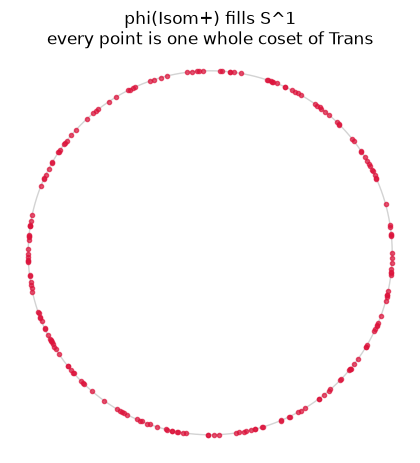

In [6]:
# The quotient map, as a picture: 200 random isometries -> 200 points of S^1.
# Everything about b has been forgotten; only the angle survives.
fig, ax = plt.subplots(figsize=(5.2, 5.2))
circle = np.exp(1j * np.linspace(0, TAU, 400))
ax.plot(circle.real, circle.imag, color="lightgray", lw=1)
img = np.array([f.phi() for f in sample])
ax.plot(img.real, img.imag, ".", ms=6, color="crimson", alpha=0.7)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("phi(Isom+) fills S^1\nevery point is one whole coset of Trans")
plt.show()


# 3. Spiral similarities: a direct product, so each factor is a quotient

Fix the origin and consider the **spiral similarities** centred there:

$$\mathrm{Spiral} = \{\, z \mapsto a z \;:\; a \in \mathbb{C}^{\times} \,\},$$

a rotation and a dilation performed together. Composition multiplies the $a$'s,
so $\mathrm{Spiral} \cong (\mathbb{C}^{\times}, \cdot)$. Writing
$a = r e^{i\theta}$ with $r > 0$ splits it cleanly:

$$\mathrm{Spiral} \;\cong\; \mathrm{Dilat}^+ \times \mathrm{Rotn}
\;\cong\; \mathbb{R}_{>0} \times S^1 .$$

A direct product hands you **two** quotients at once, because each factor is the
kernel of the projection onto the other:

$$a \mapsto |a| \quad\text{has kernel } \mathrm{Rotn}, \qquad\text{so}\qquad
\mathrm{Spiral}/\mathrm{Rotn} \cong \mathrm{Dilat}^+,$$

$$a \mapsto a/|a| \quad\text{has kernel } \mathrm{Dilat}^+, \qquad\text{so}\qquad
\mathrm{Spiral}/\mathrm{Dilat}^+ \cong \mathrm{Rotn} \cong S^1 .$$

Forget the turning and you are left with pure scale; forget the scale and you
are left with pure turning. The orbit of a point under a cyclic subgroup
$\langle a \rangle$ is a **logarithmic spiral** — and the two quotient maps are
exactly the two ways of flattening it.


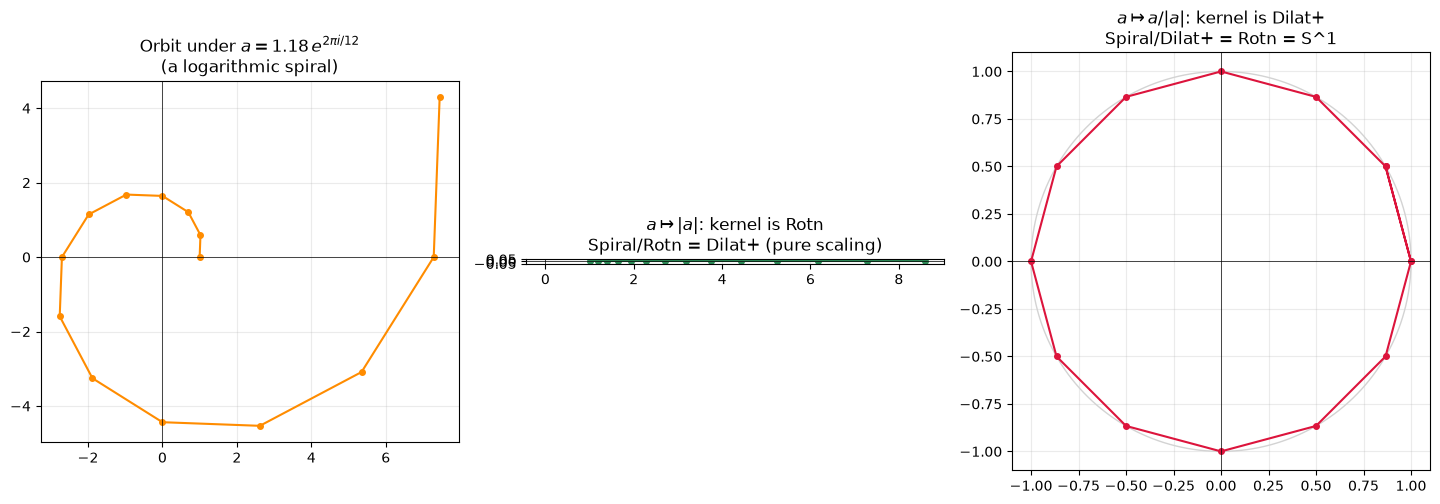

In [7]:
def orbit(a, z0=1 + 0j, k=14):
    "The forward orbit z0, a z0, a^2 z0, ... under the spiral similarity z -> a z."
    return np.array([a**j * z0 for j in range(k)])

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8))

a = 1.18 * np.exp(1j * TAU / 12)          # dilate AND rotate
o = orbit(a)
axes[0].plot(o.real, o.imag, "o-", ms=4, color="darkorange")
axes[0].set_title(r"Orbit under $a = 1.18\,e^{2\pi i/12}$" "\n(a logarithmic spiral)")

# Kill the rotation: keep only |a|. This is the image in Dilat+.
o_mod = orbit(abs(a))
axes[1].plot(o_mod.real, o_mod.imag, "o-", ms=4, color="seagreen")
axes[1].set_title(r"$a \mapsto |a|$: kernel is Rotn" "\nSpiral/Rotn = Dilat+ (pure scaling)")

# Kill the dilation: keep only a/|a|. This is the image in Rotn = S^1.
o_arg = orbit(a / abs(a))
circle = np.exp(1j * np.linspace(0, TAU, 400))
axes[2].plot(circle.real, circle.imag, color="lightgray", lw=1)
axes[2].plot(o_arg.real, o_arg.imag, "o-", ms=4, color="crimson")
axes[2].set_title(r"$a \mapsto a/|a|$: kernel is Dilat+" "\nSpiral/Dilat+ = Rotn = S^1")

for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.axhline(0, lw=0.5, c="k"); ax.axvline(0, lw=0.5, c="k")
plt.tight_layout(); plt.show()


a -> |a|      is a homomorphism: True
a -> a/|a|    is a homomorphism: True
Rotn   maps to 1 under |.|  : True
Dilat+ maps to 1 under arg  : True
nothing else does (|.|)     : True
nothing else does (arg)     : True


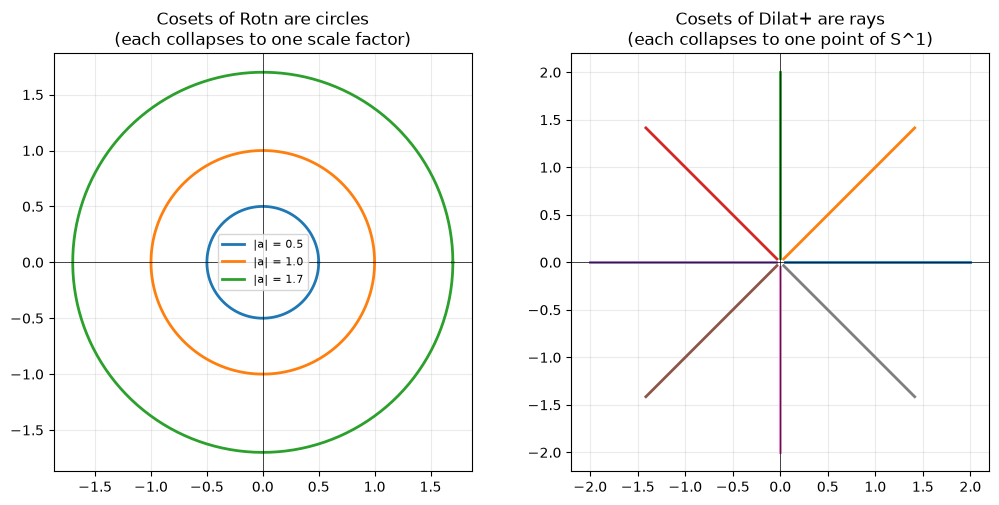

In [8]:
# Both projections are homomorphisms, and each kernel is the other factor.
rng = np.random.default_rng(1)
A = [complex(rng.normal(), rng.normal()) for _ in range(300)]
A = [a for a in A if abs(a) > 1e-6]

mod_ok = all(approx(abs(a * b), abs(a) * abs(b)) for a in A[:60] for b in A[:60])
arg_ok = all(approx((a * b) / abs(a * b), (a / abs(a)) * (b / abs(b)))
             for a in A[:60] for b in A[:60])
print("a -> |a|      is a homomorphism:", mod_ok)
print("a -> a/|a|    is a homomorphism:", arg_ok)

# ker(modulus) = the unit circle = Rotn ; ker(argument) = positive reals = Dilat+.
# Test both directions: everything in the claimed kernel maps to 1, and nothing
# outside it does. (Checking only one direction would be vacuously true here,
# since a random complex number is essentially never of unit modulus.)
rot = [np.exp(1j * t) for t in rng.uniform(0, TAU, 100)]          # Rotn
dil = [float(x) for x in rng.uniform(0.1, 5.0, 100)]              # Dilat+

print("Rotn   maps to 1 under |.|  :", all(approx(abs(a), 1) for a in rot))
print("Dilat+ maps to 1 under arg  :", all(approx(a / abs(a), 1 + 0j) for a in dil))
print("nothing else does (|.|)     :", not any(approx(abs(a), 1) for a in dil if a != 1.0))
print("nothing else does (arg)     :", not any(approx(a / abs(a), 1 + 0j)
                                               for a in rot if not approx(a, 1 + 0j)))

# A coset of Rotn is a circle; a coset of Dilat+ is an open ray from the origin.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 5))
for r in [0.5, 1.0, 1.7]:
    c = r * np.exp(1j * np.linspace(0, TAU, 300))
    axes[0].plot(c.real, c.imag, lw=2, label=f"|a| = {r}")
axes[0].legend(fontsize=8); axes[0].set_title("Cosets of Rotn are circles\n(each collapses to one scale factor)")
for th in np.arange(0, TAU, TAU / 8):
    t = np.linspace(0.05, 2.0, 50) * np.exp(1j * th)
    axes[1].plot(t.real, t.imag, lw=2)
axes[1].set_title("Cosets of Dilat+ are rays\n(each collapses to one point of S^1)")
for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25)
    ax.axhline(0, lw=0.5, c="k"); ax.axvline(0, lw=0.5, c="k")
plt.tight_layout(); plt.show()


**Companion applets.** Two interactive lessons from
[The Erlangen Program, Concretely](https://supernumero.us/erlangen-program/)
show these groups acting directly, with no code in the way:

- [Groups of spiral similarities](https://supernumero.us/erlangen-program/spiral-groups.html)
- [Groups of translations](https://supernumero.us/erlangen-program/lattice-groups.html)


# 4. A finite example: $S_4/A_4 \cong \{\pm 1\}$

Not every quotient is geometric. The **sign** homomorphism
$\operatorname{sgn}\colon S_n \to \{\pm 1\}$ sends a permutation to $+1$ if it is
a product of an even number of transpositions and $-1$ otherwise. Its kernel is
the alternating group $A_n$, so

$$S_n/A_n \cong \{\pm 1\} \cong \mathbb{Z}/2 .$$

Two cosets, and the quotient answers exactly one question about a permutation:
*is it even?*


In [9]:
def sign(p):
    "Sign of a permutation given as a tuple, by counting inversions."
    inv = sum(1 for i, j in itertools.combinations(range(len(p)), 2) if p[i] > p[j])
    return -1 if inv % 2 else 1

def compose(p, q):
    return tuple(p[q[i]] for i in range(len(q)))

S4 = list(itertools.permutations(range(4)))
A4 = [p for p in S4 if sign(p) == 1]
odd = [p for p in S4 if sign(p) == -1]

print(f"|S4| = {len(S4)},  |A4| = {len(A4)},  |odd coset| = {len(odd)}")
print("index [S4 : A4] =", len(S4) // len(A4))

bad = [(p, q) for p in S4 for q in S4 if sign(compose(p, q)) != sign(p) * sign(q)]
print("homomorphism failures:", len(bad))

# The two cosets, and the Z/2 multiplication they induce.
print("\neven * even -> even :", all(sign(compose(p, q)) == 1 for p in A4 for q in A4))
print("even * odd  -> odd  :", all(sign(compose(p, q)) == -1 for p in A4 for q in odd))
print("odd  * odd  -> even :", all(sign(compose(p, q)) == 1 for p in odd for q in odd))


|S4| = 24,  |A4| = 12,  |odd coset| = 12
index [S4 : A4] = 2
homomorphism failures: 0

even * even -> even : True
even * odd  -> odd  : True
odd  * odd  -> even : True


# 5. The pattern

Every example above is the same theorem wearing different clothes.

| $G$ | $\varphi$ remembers | $N = \ker\varphi$ (forgotten) | $G/N \cong \operatorname{im}\varphi$ |
|---|---|---|---|
| $\mathbb{Z}$ | remainder mod $n$ | $n\mathbb{Z}$ | $\mathbb{Z}/n$ |
| $\mathrm{Isom}^+$ | how far it turned | $\mathrm{Trans} \cong \mathbb{R}^2$ | $S^1 \cong \mathrm{SO}(2)$ |
| $\mathrm{Spiral}$ | the scale factor $\lvert a\rvert$ | $\mathrm{Rotn} \cong S^1$ | $\mathrm{Dilat}^+ \cong \mathbb{R}_{>0}$ |
| $\mathrm{Spiral}$ | the direction $a/\lvert a\rvert$ | $\mathrm{Dilat}^+$ | $\mathrm{Rotn} \cong S^1$ |
| $S_4$ | parity | $A_4$ | $\{\pm 1\} \cong \mathbb{Z}/2$ |

Two things are worth carrying away.

**A quotient is a deliberate act of forgetting.** Choosing $N$ is choosing what
you refuse to distinguish. $\mathbb{Z}/n$ refuses to distinguish integers with
the same remainder; $\mathrm{Isom}^+/\mathrm{Trans}$ refuses to distinguish
figures that differ by a slide.

**A direct product is the easy case.** When $G \cong H \times K$ you get both
quotients for free, and each factor is the other's kernel. Most groups are *not*
direct products, which is why the general theory needs normality rather than
just a subgroup.


# 6. Things to try

No submission, no grade. Work in a group if you like; the last two are the
interesting ones.

1. **Orientation-reversing isometries.** The full isometry group
   $\mathrm{Isom}$ also contains $z \mapsto e^{i\theta}\bar{z} + b$. Is
   $\mathrm{Trans}$ still normal in $\mathrm{Isom}$? What is
   $\mathrm{Isom}/\mathrm{Trans}$ now — is it still $S^1$? Modify the `Isom`
   class to carry a conjugation flag and test it.
2. **A subgroup that is not normal.** Inside $\mathrm{Isom}^+$, take the
   rotations about the point $1$ rather than about $0$. Conjugate one of them by
   a translation and see what you get. Why does this block forming a quotient?
3. **Finite spirals.** Which $a \in \mathbb{C}^\times$ generate a *finite*
   subgroup of $\mathrm{Spiral}$? Draw an orbit for one. What does your answer
   say about $\mathrm{Dilat}^+$?
4. **$\mathbb{Z}/n$ from the circle.** The map $t \mapsto e^{2\pi i t}$ sends
   $\mathbb{R} \to S^1$ with kernel $\mathbb{Z}$, so $\mathbb{R}/\mathbb{Z}
   \cong S^1$. Where does $\mathbb{Z}/n$ sit inside that picture? Draw it.
5. **Composing quotients.** $\mathrm{Isom}^+ \to S^1$ forgets translation;
   $S^1 \to S^1$, $w \mapsto w^n$, forgets more. What is the kernel of the
   composite, and what does the quotient look like geometrically?


---
## License

This notebook is released under the [Creative Commons Attribution 4.0
International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/). You are free to copy, adapt,
and redistribute it, including for commercial purposes, provided you give
appropriate credit.

Suggested attribution: *"Quotients and Homomorphic Images" by [Eduardo Dueñez](https://supernumero.us/about),
licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*
